## Assignment: Sequence Modeling with RNN and LSTM **[30 points]**

## Objective
In this assignment, you will learn how to use **Recurrent Neural Networks (RNNs)** and **Long Short-Term Memory (LSTM)** networks to model sequential data. You will build and compare RNN and LSTM models on a **sentiment analysis task** using text data.

---

## Part 1: Dataset Selection and Preprocessing

You will use the **IMDb Movie Reviews Dataset**, which contains 50,000 movie reviews labeled as positive or negative.

- Load the dataset using `tensorflow.keras.datasets.imdb`
- Limit the vocabulary size (e.g., top 10,000 most frequent words)
- Pad sequences to a uniform length (e.g., 200 words)

```python
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
vocab_size = 10000
max_len = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
```

---

## Part 2: Build and Train an RNN Model

### Task:
- Build a simple RNN model using Keras
- Include an `Embedding` layer followed by a `SimpleRNN` and a `Dense` output
- Compile and train the model
- Plot training and validation accuracy

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_rnn.summary()
history_rnn = model_rnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
```

---

## Part 3: Replace RNN with LSTM and Compare

### Task:
- Build a similar model, but replace `SimpleRNN` with `LSTM`
- Train and evaluate the model
- Plot and compare the performance with the RNN model

```python
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
```

---

## Part 4: Experimentation and Tuning

### Tasks:
- Vary the number of hidden units (e.g., 32, 64, 128)
- Try multiple layers of RNN/LSTM
- Experiment with dropout
- Try `Bidirectional` wrappers for LSTM
- Compare validation performance across settings

---

## Part 5: Questions and Reflections

1. Which model performed better on the test data, RNN or LSTM? Why?
2. What differences do you observe in learning curves and overfitting behavior?
3. How does increasing the number of units or layers affect performance?
4. Why does LSTM perform better on longer sequences compared to a vanilla RNN?

---

## Hints
- You may try early stopping for model selection to reduce overfitting


Part 1: Dataset Selection and Preproccessing

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

vocab_size = 10000
max_len = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)
y_train shape: (25000,)
y_test shape: (25000,)


In [3]:
def plot_history(history, title):
    plt.figure(figsize=(8, 5))

    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

Part 2: Build and Train an RNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64),
    SimpleRNN(64),
    Dense(1, activation="sigmoid")
])

model_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6641 - loss: 0.5910 - val_accuracy: 0.8226 - val_loss: 0.4066
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8490 - loss: 0.3511 - val_accuracy: 0.8438 - val_loss: 0.3858
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.8882 - loss: 0.2764 - val_accuracy: 0.8210 - val_loss: 0.4782
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9458 - loss: 0.1502 - val_accuracy: 0.8030 - val_loss: 0.5786
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9751 - loss: 0.0757 - val_accuracy: 0.7616 - val_loss: 0.7242


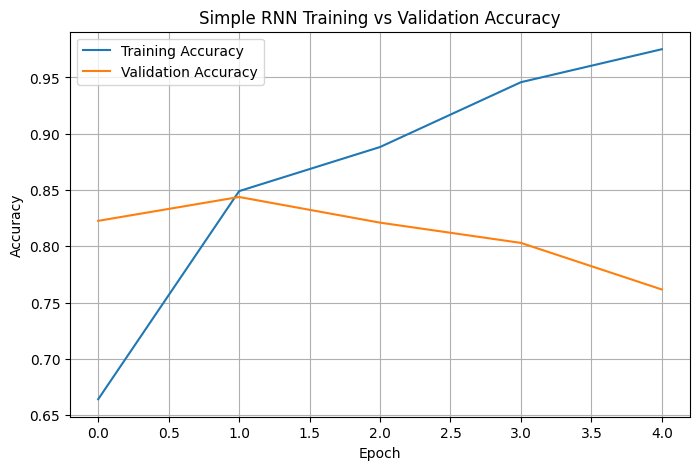

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7653 - loss: 0.7250
RNN Test Loss: 0.7250046730041504
RNN Test Accuracy: 0.7653200030326843


In [6]:
plot_history(history_rnn, "Simple RNN Training vs Validation Accuracy")

rnn_loss, rnn_accuracy = model_rnn.evaluate(X_test, y_test)

print("RNN Test Loss:", rnn_loss)
print("RNN Test Accuracy:", rnn_accuracy)

Part 3: Replace RNN with LSTM and Compare

In [7]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 76ms/step - accuracy: 0.7768 - loss: 0.4515 - val_accuracy: 0.8632 - val_loss: 0.3346
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.8981 - loss: 0.2594 - val_accuracy: 0.8668 - val_loss: 0.3197
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.9257 - loss: 0.2021 - val_accuracy: 0.8524 - val_loss: 0.3493
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.9352 - loss: 0.1756 - val_accuracy: 0.8652 - val_loss: 0.3761
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9441 - loss: 0.1515 - val_accuracy: 0.8458 - val_loss: 0.4587


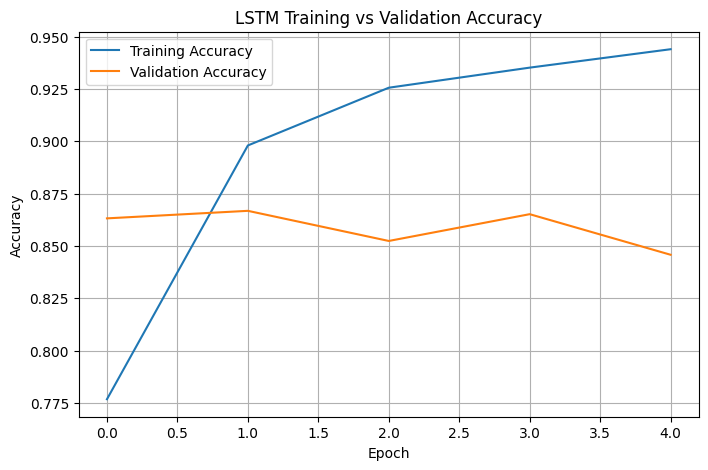

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8507 - loss: 0.4551
LSTM Test Loss: 0.45514899492263794
LSTM Test Accuracy: 0.8507199883460999


In [8]:
plot_history(history_lstm, "LSTM Training vs Validation Accuracy")

lstm_loss, lstm_accuracy = model_lstm.evaluate(X_test, y_test)

print("LSTM Test Loss:", lstm_loss)
print("LSTM Test Accuracy:", lstm_accuracy)

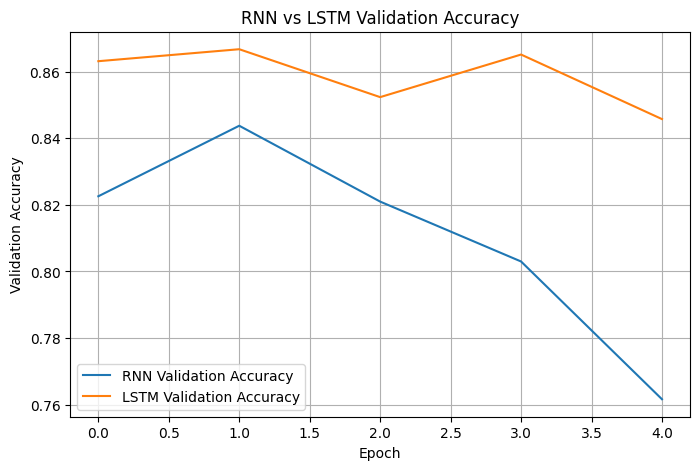

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["val_accuracy"], label="RNN Validation Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="LSTM Validation Accuracy")

plt.title("RNN vs LSTM Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Part 4: Experimentation and Tuning

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

unit_values = [32, 64, 128]
results_units = {}

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

for units in unit_values:
    print(f"\nTraining LSTM with {units} units")

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
        LSTM(units),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    results_units[units] = {
        "val_accuracy": max(history.history["val_accuracy"]),
        "test_accuracy": test_acc
    }

print(results_units)


Training LSTM with 32 units
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.7958 - loss: 0.4334 - val_accuracy: 0.8744 - val_loss: 0.3095
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.9033 - loss: 0.2484 - val_accuracy: 0.8606 - val_loss: 0.3213
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.9197 - loss: 0.2089 - val_accuracy: 0.8702 - val_loss: 0.3140

Training LSTM with 64 units
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.7538 - loss: 0.4766 - val_accuracy: 0.8740 - val_loss: 0.3165
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.8965 - loss: 0.2622 - val_accuracy: 0.8476 - val_loss: 0.3802

Training LSTM with 128 units
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 163ms/step - accuracy: 0.7794 - loss: 0.4540 - val_accuracy: 0.8498 - val_loss: 0.3480
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - accuracy: 0.8791 - loss: 0.2960 - val_accuracy: 0.8562 - val_loss: 0.3574
{32: {'

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 125ms/step - accuracy: 0.7421 - loss: 0.5171 - val_accuracy: 0.8096 - val_loss: 0.4176
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.8450 - loss: 0.3645 - val_accuracy: 0.7906 - val_loss: 0.4479
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8173 - loss: 0.4132
LSTM with Dropout Test Accuracy: 0.8173199892044067


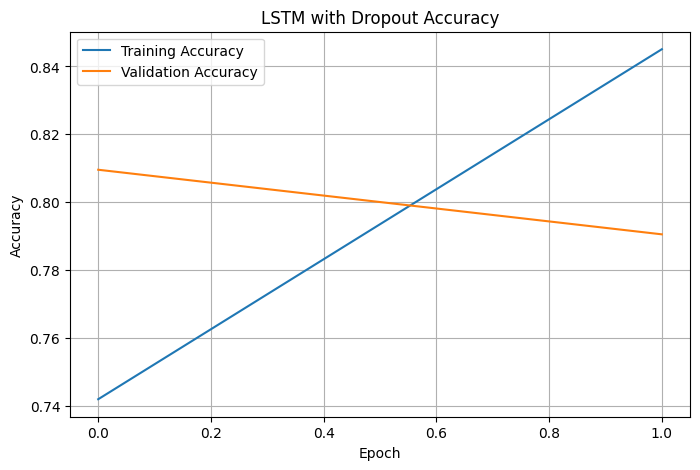

In [11]:
from tensorflow.keras.layers import Dropout

model_lstm_dropout = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(1, activation="sigmoid")
])

model_lstm_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_lstm_dropout = model_lstm_dropout.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

dropout_loss, dropout_accuracy = model_lstm_dropout.evaluate(X_test, y_test)

print("LSTM with Dropout Test Accuracy:", dropout_accuracy)

plot_history(history_lstm_dropout, "LSTM with Dropout Accuracy")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.7993 - loss: 0.4245 - val_accuracy: 0.8780 - val_loss: 0.3043
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.9061 - loss: 0.2468 - val_accuracy: 0.8730 - val_loss: 0.3235
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 107ms/step - accuracy: 0.9309 - loss: 0.1909 - val_accuracy: 0.8718 - val_loss: 0.3670
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8684 - loss: 0.3162
Stacked LSTM Test Accuracy: 0.8683599829673767


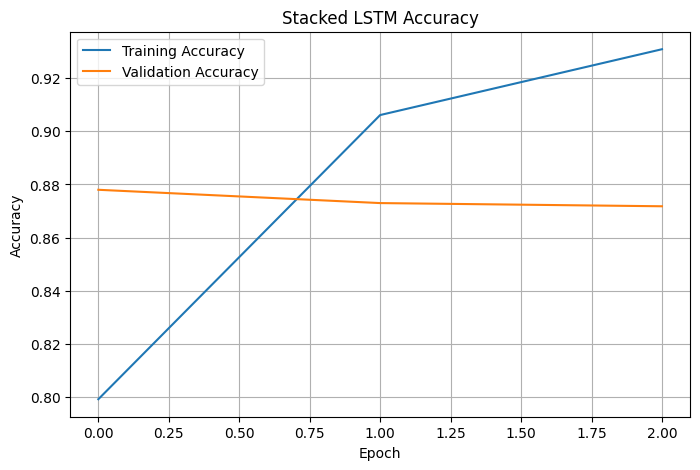

In [12]:
model_stacked_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

model_stacked_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_stacked_lstm = model_stacked_lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

stacked_loss, stacked_accuracy = model_stacked_lstm.evaluate(X_test, y_test)

print("Stacked LSTM Test Accuracy:", stacked_accuracy)

plot_history(history_stacked_lstm, "Stacked LSTM Accuracy")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - accuracy: 0.7638 - loss: 0.4714 - val_accuracy: 0.8402 - val_loss: 0.3637
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.8960 - loss: 0.2622 - val_accuracy: 0.8602 - val_loss: 0.3286
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8468 - loss: 0.3597
Bidirectional LSTM Test Accuracy: 0.8468400239944458


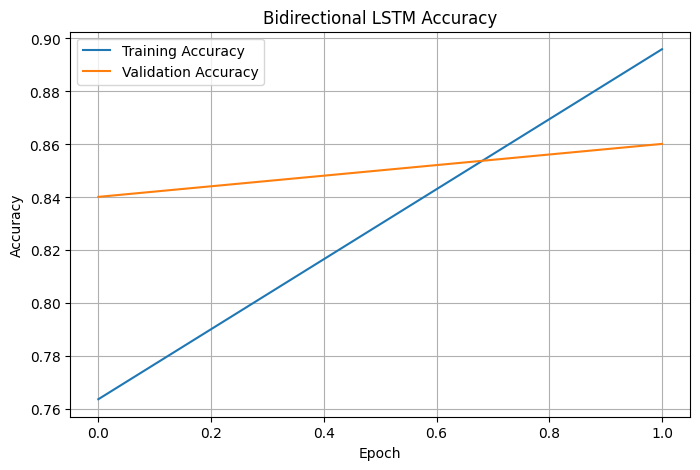

In [13]:
from tensorflow.keras.layers import Bidirectional

model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dense(1, activation="sigmoid")
])

model_bilstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_bilstm = model_bilstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

bilstm_loss, bilstm_accuracy = model_bilstm.evaluate(X_test, y_test)

print("Bidirectional LSTM Test Accuracy:", bilstm_accuracy)

plot_history(history_bilstm, "Bidirectional LSTM Accuracy")

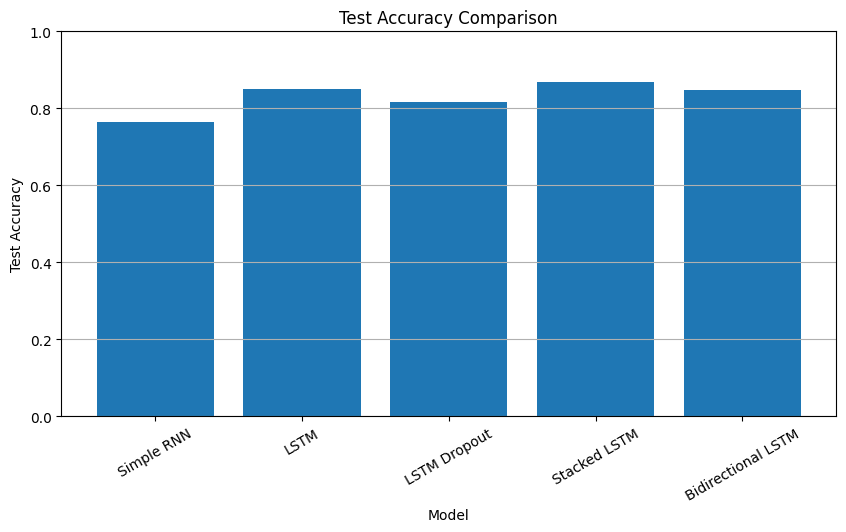

Simple RNN: 0.7653
LSTM: 0.8507
LSTM Dropout: 0.8173
Stacked LSTM: 0.8684
Bidirectional LSTM: 0.8468


In [14]:
model_names = [
    "Simple RNN",
    "LSTM",
    "LSTM Dropout",
    "Stacked LSTM",
    "Bidirectional LSTM"
]

test_accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    dropout_accuracy,
    stacked_accuracy,
    bilstm_accuracy
]

plt.figure(figsize=(10, 5))
plt.bar(model_names, test_accuracies)
plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

for name, acc in zip(model_names, test_accuracies):
    print(f"{name}: {acc:.4f}")

Part 5: Questions and Reflections:

1. The LSTM model performed better than the RNN model. The simple RNN model had a test accurracy of 0.7653 and the LSTM model had a test accuracy of 0.8507. The RNN model has difficulty remembering long-term dependencies because as the sequence increases, information from earlier steps fades. LSTM networks are designed in such a way that long-term dependencies are remembered at large step sizes which leads to better performance.

2. The RNN's validation accuracy quickly deteriorates and becomes unstable as the number of training epochs increases as well as showing signs of overfitting. The LSTM had a smoother learning curve and displayed less overfitting than the RNN at higher training epochs. This is likely because LSTM networks are designed to remember long-term dependencies while RNN networks are not.

3. Increasing the number of units or layers when using LSTM does generally increase model performance. This is because LSTM networks are designed to remember long-term dependencies, so adding more layers is beneficial. There is an increase in computational cost because adding more units and layers does make the model more complex. Adding too many units can also cause overfitting.

4. LSTM networks use gates to decide which information to store as well as pass on to the next step. This allows LSTMs to be more efficient and perform better at longer sequences when compared to RNNs, which do not use the gate structure that LSTMs use.

# Exercise-2: Kernel Perceptron on Quadratically Separable Data **[20 points]**

**Objective:**  
Explore the limitations of linear classifiers and implement a kernelized perceptron to classify data that is not linearly separable but separable in a higher-order feature space using a kernel function.

---

## Q1: Dataset Generation – Quadratically Separable Data

**(a)** Generate a 2D dataset by sampling 100 data points from a standard 2D Gaussian distribution centered at the origin.  
*(Hint: use `np.random.randn(100, 2)`)* - 5 points

**(b)** Label the data using the following rule:  
  Assign class **+1** if $x_1^2 + x_2^2 > 1$, otherwise assign class **-1**. - 5 points

**(c)** Visualize the dataset - 10 points:  
- Plot the points using color to indicate class labels.  
- Optionally overlay the circular decision boundary ($x_1^2 + x_2^2 = 1$).  
- Include axis labels and a legend.

---

## Q2: Kernel Perceptron Implementation

**(a)** Implement the **kernelized perceptron** algorithm using a **polynomial kernel** - 5 points:  
  $K(x, x') = (\langle x, x' \rangle + 1)^d$, with $d = 2$

**(b)** Train the kernel perceptron on the dataset and predict on the training data. - 5 points

**(c)** Visualize the predicted classes. - 5 points

---

## Q3: Kernel Choice & Experiments (Optional)

**(a)** Try different values of the polynomial degree $d$ (e.g., 1, 2, 3, 5). How does the performance change? - 5 points

**(b)**  Replace the polynomial kernel with a **Gaussian RBF kernel** and re-run the experiment. - 5 points

**(c)** Compare and comment on the results with different kernels. -  5 points

---














Q1: Dataset Generation – Quadratically Separable Data

In [15]:
X = np.random.randn(100, 2)

print(X.shape)

(100, 2)


In [16]:
y = np.where(X[:, 0]**2 + X[:, 1]**2 > 1, 1, -1)

print(y)

[-1  1 -1  1 -1 -1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1 -1  1  1
  1 -1 -1  1 -1  1 -1  1  1  1 -1  1  1  1 -1  1 -1  1 -1 -1 -1 -1 -1  1
 -1 -1  1 -1 -1  1 -1  1  1 -1  1  1  1  1  1  1 -1  1  1  1 -1  1  1  1
 -1  1 -1 -1 -1 -1  1  1  1  1  1  1 -1  1 -1 -1  1  1  1  1 -1 -1  1 -1
  1 -1 -1  1]


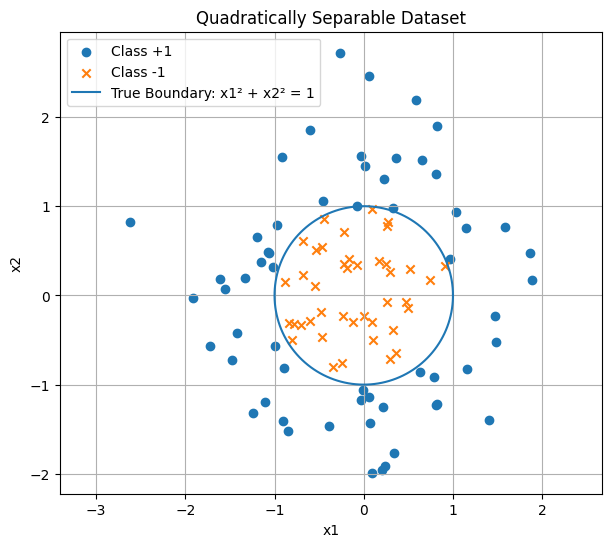

In [17]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class +1",
    marker="o"
)

plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    label="Class -1",
    marker="x"
)

theta = np.linspace(0, 2 * np.pi, 300)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

plt.plot(circle_x, circle_y, label="True Boundary: x1² + x2² = 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Quadratically Separable Dataset")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

Q2: Kernel Perceptron Implementation

In [18]:
def polynomial_kernel(x, z, degree=2):
    return (np.dot(x, z) + 1) ** degree

class KernelPerceptron:
    def __init__(self, kernel, epochs=10):
        self.kernel = kernel
        self.epochs = epochs
        self.alpha = None
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        n_samples = X.shape[0]

        self.alpha = np.zeros(n_samples)
        self.X_train = X
        self.y_train = y

        for epoch in range(self.epochs):
            errors = 0

            for i in range(n_samples):
                prediction = self.predict_one(X[i])

                if prediction != y[i]:
                    self.alpha[i] += 1
                    errors += 1

            print(f"Epoch {epoch + 1}: mistakes = {errors}")

            if errors == 0:
                break

    def predict_one(self, x):
        total = 0

        for i in range(len(self.X_train)):
            if self.alpha[i] != 0:
                total += (
                    self.alpha[i]
                    * self.y_train[i]
                    * self.kernel(self.X_train[i], x)
                )

        return 1 if total >= 0 else -1

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

In [19]:
degree = 2

kernel = lambda x, z: polynomial_kernel(x, z, degree=degree)

kp = KernelPerceptron(kernel=kernel, epochs=20)

kp.fit(X, y)

y_pred = kp.predict(X)

accuracy = np.mean(y_pred == y)

print("Training Accuracy:", accuracy)

Epoch 1: mistakes = 20
Epoch 2: mistakes = 9
Epoch 3: mistakes = 8
Epoch 4: mistakes = 4
Epoch 5: mistakes = 0
Training Accuracy: 1.0


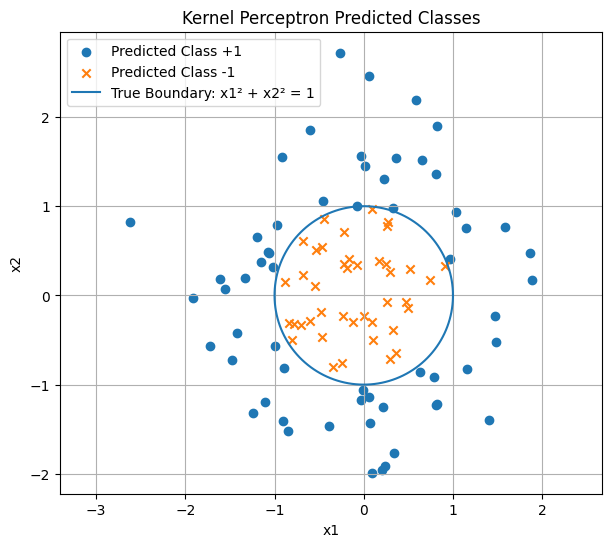

In [20]:
plt.figure(figsize=(7, 6))

plt.scatter(
    X[y_pred == 1, 0],
    X[y_pred == 1, 1],
    label="Predicted Class +1",
    marker="o"
)

plt.scatter(
    X[y_pred == -1, 0],
    X[y_pred == -1, 1],
    label="Predicted Class -1",
    marker="x"
)

plt.plot(circle_x, circle_y, label="True Boundary: x1² + x2² = 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Kernel Perceptron Predicted Classes")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()